# Phase 3 — graph construction

Validates the two graph sequences built in `src/graphs/`:

- **Part A** (`construct.py` → `graphs.npz`) — correlation kNN. Trailing 252
  sessions, market mode removed by PCA, Ledoit–Wolf shrunk correlation, k=10
  neighbours, union-symmetrised.
- **Part B** (`mutual_info.py` → `graphs_mi.npz`) — the same topology with
  mutual information swapped in for Pearson correlation.

Only the similarity measure differs between them, so any difference in the
results is attributable to that choice alone. That is the whole experiment.

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
print("anchored at:", ROOT)

anchored at: /Users/tony/Library/Mobile Documents/com~apple~CloudDocs/equity-graph-clustering


## Load Part A

`A` is the weighted adjacency `[T, N, N]`, `C` the shrunk correlation matrices
over the same windows. Both are indexed by the month-end rebalance clock and
share the ticker order of the Phase 2 feature tensor.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
d = np.load('data/processed/graphs.npz', allow_pickle=True)
A, C = d['A'], d['C']
dates = pd.to_datetime(d['dates']); tickers = list(d['tickers'])

## Check 1 — is the graph dynamic?

Jaccard overlap between each date's edge set and the previous date's. This is
the sanity check on the study's premise: near 1 and the graph never changes,
so there is nothing temporal to model; near 0 and it is noise, so no clustering
built on it will be stable. The shaded band marks the 0.6–0.85 target.

Mean is **0.746**. Read the dips, not the level — consecutive 252-day windows
share ~92% of their observations, so a high score is partly mechanical. The
trough at **2020-03-31 (0.329)** is far too deep to be mechanical: the
correlation structure genuinely reorganised through the COVID crash.

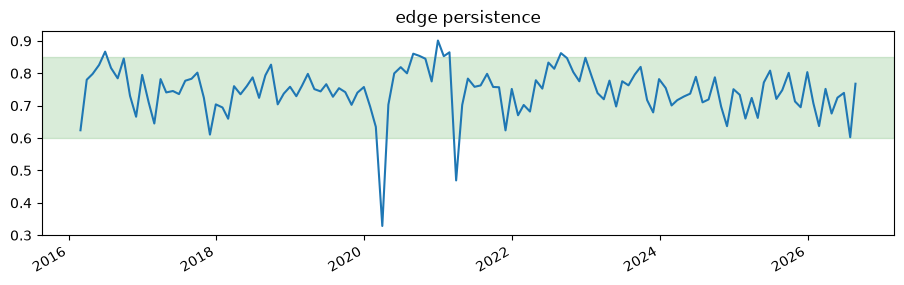

In [3]:
from src.graphs.construct import edge_persistence
p = [edge_persistence(A[i], A[i+1]) for i in range(len(A)-1)]
pd.Series(p, index=dates[1:]).plot(figsize=(11,3), title='edge persistence')
plt.axhspan(0.6, 0.85, alpha=0.15, color='green'); plt.show()

## Check 2 — is there signal above the noise floor?

With N=105 series and T=252 observations, q = N/T = 0.42, and Marchenko–Pastur
places the pure-noise upper edge at (1+√q)² = **2.708**. Eigenvalues below that
are consistent with a random matrix and carry no information.

The market mode has already been projected out, so the enormous first
eigenvalue is gone and what remains above the edge is genuine sector-level
structure. A count of zero here would mean the graph is built on noise.

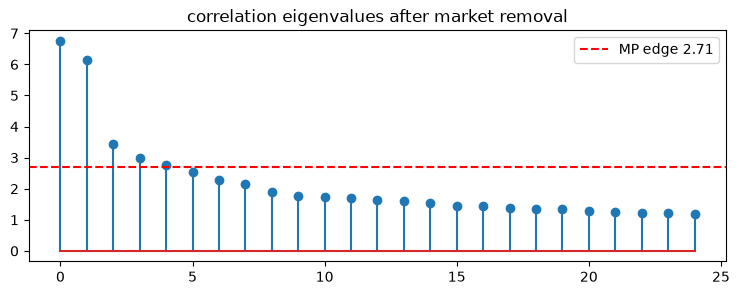

eigenvalues above MP edge: 5


In [4]:
from src.graphs.construct import marchenko_pastur_edge
i = dates.get_loc(pd.Timestamp('2019-06-28'))   # a quiet period
w = np.linalg.eigvalsh(C[i])[::-1]
mp = marchenko_pastur_edge(105, 252)
plt.figure(figsize=(9,3))
plt.stem(w[:25]); plt.axhline(mp, color='r', ls='--', label=f'MP edge {mp:.2f}')
plt.legend(); plt.title('correlation eigenvalues after market removal'); plt.show()
print('eigenvalues above MP edge:', (w > mp).sum())

## Check 3 — does the structure line up with sectors?

Permute the adjacency into sector blocks and look for density on the diagonal.
Sector membership plays no part in construction — the graph sees only returns —
so block structure appearing here is independent corroboration that the edges
are economically meaningful rather than an artefact of the estimator.

The ticker join needs care: see the comment in the cell for why joining on the
raw `yahoo_ticker` column silently corrupts this plot.

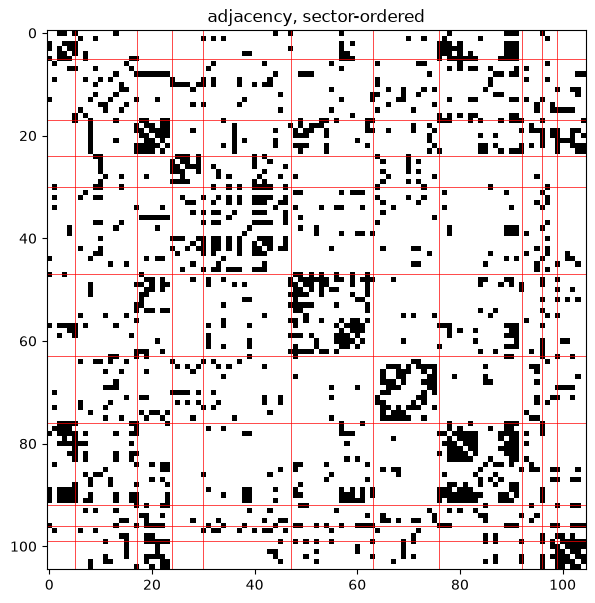

In [5]:
uni = pd.read_csv('data/universe_sp100.csv')

# The CSV stores Yahoo symbols with a dot (BRK.B); src/data/ingest.py
# normalises those to a dash (BRK-B) before download, so that is what the
# panel and every artefact downstream carry. Joining on the raw column leaves
# BRK-B unmatched, and a single NaN sector is enough to (a) misplace that name
# in the sector ordering below and (b) make sorted(sec.unique()) raise, since
# NaN is a float and the rest are strings.
sec = (uni.assign(key=uni['yahoo_ticker'].str.replace('.', '-', regex=False))
          .set_index('key')['sector']
          .reindex(tickers))
assert sec.notna().all(), f"no sector for {list(sec[sec.isna()].index)}"

order = np.argsort(sec.values)
plt.figure(figsize=(7,7))
sec_ordered = sec.values[order]                       # sectors in plot order
bounds = np.where(sec_ordered[1:] != sec_ordered[:-1])[0] + 1
for b in bounds:
    plt.axhline(b, c='r', lw=0.5); plt.axvline(b, c='r', lw=0.5)
plt.imshow(A[60][np.ix_(order, order)] != 0, cmap='Greys', interpolation='nearest')
plt.title('adjacency, sector-ordered'); plt.show()

Sorting by sector must produce exactly one boundary between each pair of
adjacent blocks. If this count is one too high, a name failed the sector join
and `argsort` has parked its NaN at the end — the assertion catches that rather
than leaving it to be noticed by eye.

In [6]:
# One boundary between each pair of adjacent sector blocks.
print(len(bounds), sec.nunique() - 1)
assert len(bounds) == sec.nunique() - 1

10 10


## Load Part B

`M` holds the raw mutual information matrices in nats and `Delta` the
nonlinear excess, `MI − (−½ln(1−ρ²))`: the dependence that linear correlation
does not explain.

In [7]:
mi = np.load('data/processed/graphs_mi.npz', allow_pickle=True)
M, Delta = mi['M'], mi['Delta']
mi_dates = pd.to_datetime(mi['dates'])

The MI run can be built on a subset of dates (`mi.subsample_dates`), so its
date axis is not guaranteed to match Part A's. `sel` maps each MI date to its
position in the Part A stack, and everything downstream indexes through it
rather than assuming the two line up.

In [8]:
sel = [list(dates).index(d) for d in mi_dates]
C_sub = C[sel]

## Check 4 — does MI agree with the Gaussian benchmark?

For a bivariate Gaussian pair, MI is exactly −½ln(1−ρ²). Plotting estimated MI
against that prediction puts every pair on one chart: points on the red line
are pairs whose dependence is fully described by correlation.

Scatter *above* the line is nonlinear dependence, or estimator bias — this plot
alone cannot separate the two, which is what the null floor below is for.
Systematic deviation *below* the line would mean the estimator is broken.

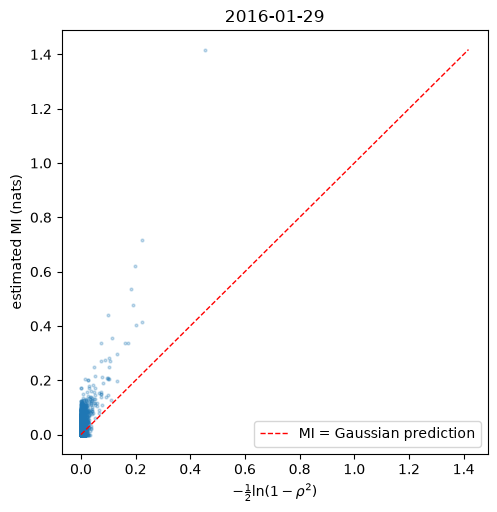

In [9]:
from src.graphs.mutual_info import gaussian_mi
iu = np.triu_indices(105, 1)
t = 0
rho = C_sub[t][iu]; mi_obs = M[t][iu]

plt.figure(figsize=(5.5,5.5))
plt.scatter(gaussian_mi(rho), mi_obs, s=4, alpha=0.25)
lim = max(gaussian_mi(rho).max(), mi_obs.max())
plt.plot([0, lim], [0, lim], 'r--', lw=1, label='MI = Gaussian prediction')
plt.xlabel('$-\\frac{1}{2}\\ln(1-\\rho^2)$'); plt.ylabel('estimated MI (nats)')
plt.legend(); plt.title(f'{mi_dates[t].date()}'); plt.show()

## Check 5 — how much of the excess is real?

The distribution of Δ across every pair and date. The red line is the 95th
percentile of a permutation null, obtained by shuffling one series of a pair to
destroy dependence while preserving its marginal distribution.

This null is necessary because **MI is non-negative**: sampling error has
nowhere to cancel, so independent series still return MI > 0. Correlation needs
no such correction, since its errors are signed and average out. Mass to the
right of the red line is the part of the excess that noise alone does not
explain.

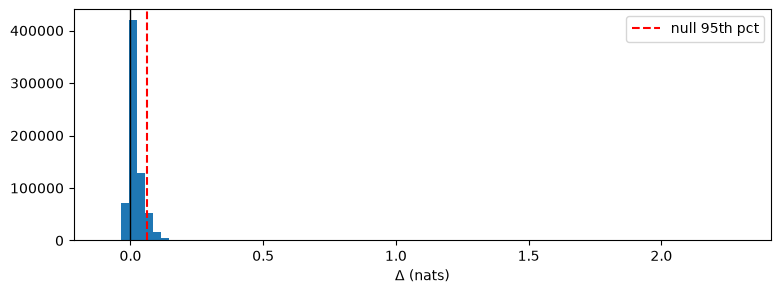

fraction above null: 8.95%


In [10]:
vals = np.concatenate([Delta[t][iu] for t in range(len(Delta))])
plt.figure(figsize=(9,3))
plt.hist(vals, bins=80)
plt.axvline(0, color='k', lw=1)
null_p95 = 0.0613
plt.axvline(null_p95, color='r', ls='--', label='null 95th pct')   # from the run log
plt.legend(); plt.xlabel('$\\Delta$ (nats)'); plt.show()
print(f"fraction above null: {(vals > null_p95).mean():.2%}")

### Correlation vs mutual-information topology, same date

One spring layout, computed from the correlation graph and reused for both
panels, so a node sits in the same place in each and only its edges change.
That is the only way the two are visually comparable -- laying each out
independently would show two different pictures of two different graphs.

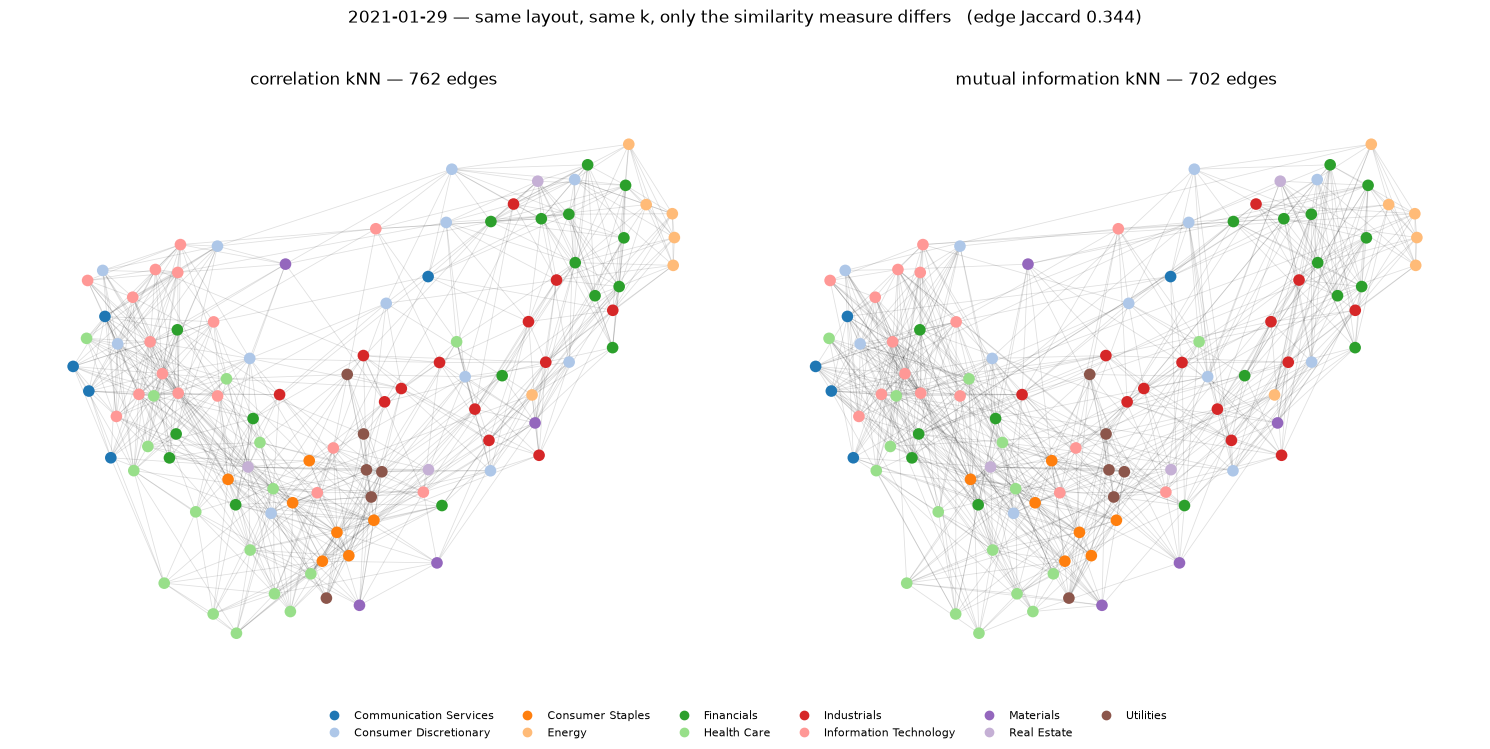

In [11]:
import networkx as nx

t    = 60                                   # a mid-sample date
t_mi = sel.index(t)                         # the same calendar date in the MI stack
assert dates[t] == mi_dates[t_mi], "date misalignment between the two artefacts"

sectors = sorted(sec.unique())
assert len(sectors) <= len(plt.cm.tab20.colors), \
    f"{len(sectors)} sectors but tab20 only has {len(plt.cm.tab20.colors)} colours"
palette = dict(zip(sectors, plt.cm.tab20.colors))
cols    = [palette[s] for s in sec]

# .astype(int) so networkx reads an adjacency matrix rather than a bool mask.
G_corr = nx.from_numpy_array((A[t] != 0).astype(int))
G_mi   = nx.from_numpy_array((mi['A'][t_mi] != 0).astype(int))
pos    = nx.spring_layout(G_corr, seed=42, k=0.35, iterations=200)

jac = edge_persistence(A[t], mi['A'][t_mi])

fig, axes = plt.subplots(1, 2, figsize=(15, 7.5))
for ax, G, title in [(axes[0], G_corr, 'correlation kNN'),
                     (axes[1], G_mi,   'mutual information kNN')]:
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.12, width=0.6)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=70,
                           node_color=cols, linewidths=0)
    ax.set_title(f'{title} — {G.number_of_edges()} edges')
    ax.axis('off')

handles = [plt.Line2D([], [], marker='o', ls='', color=palette[s], label=s)
           for s in sectors]
fig.legend(handles=handles, loc='lower center', ncol=6, frameon=False, fontsize=8)
fig.suptitle(f'{dates[t].date()} — same layout, same k, only the similarity '
             f'measure differs   (edge Jaccard {jac:.3f})')
plt.tight_layout(rect=(0, 0.06, 1, 0.96)); plt.show()